# Nuestro trabajo 1 — extensión discreta WPEB + metaheurísticas (Colab)

Este notebook implementa una **replicación reproducible y extensible** del paper:

**Li et al. (2024)**, *Capacity optimization of a wind-photovoltaic-electrolysis-battery (WPEB) hybrid energy system for power and hydrogen generation*.

## Qué replica este notebook
- Selección de **año meteorológico típico** usando **complementariedad viento-solar**:
  - coeficiente de Pearson por día,
  - clasificación en 9 clases,
  - distancia euclidiana al patrón de largo plazo,
  - elección del año típico.
- Simulación **8760 h** de un sistema **WPEB**.
- Optimización de capacidad con:
  - capacidad total fija de **200 MW** para `Wind + PV`,
  - restricción `AGSR <= 20%`,
  - `Electrolyzer <= 50% * (Wind + PV)`,
  - batería con potencia igual al **30%** de la capacidad del electrolizador.
- Cálculo de:
  - **LCOE**,
  - **LCOH**,
  - energía vendida a red,
  - factor de capacidad del electrolizador.

## Importante
Esta es una **replicación orientada a implementación**. El paper entrega la estructura general, las restricciones, costos y resultados objetivo, pero **no publica todos los detalles operacionales finos** del modelo base referenciado en su trabajo previo (por ejemplo, algunas ecuaciones internas exactas del despacho, pérdidas detalladas, formulación completa del NPC con todos los componentes secundarios, o la implementación completa del modelo de ref. [59]).  
Por eso este notebook busca ser:

1. **fiel al diseño experimental del paper**, y  
2. **útil como línea base de investigación** para que luego insertemos nuestros algoritmos.

Si quieres, después puedo darte una **versión 2** donde reemplazamos la búsqueda exhaustiva por **PSO / GA / GWO / LB² / metaheurística híbrida**.

In [7]:
# Si estás en Colab, descomenta la siguiente línea:
# !pip -q install requests pandas numpy matplotlib scipy tqdm

In [8]:
import copy
import math
import json
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass, asdict
from typing import Dict, Tuple, List, Optional
from scipy.stats import pearsonr
from tqdm.auto import tqdm

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1) Parámetros globales

El paper trabaja en **Damao Banner, Baotou, Inner Mongolia**, usando datos horarios NASA POWER entre **2001 y 2021**, y mantiene `Wind + PV = 200 MW`.  
Aquí dejamos las coordenadas como aproximadas y fácilmente editables.

In [9]:
CONFIG = {
    # Coordenadas aproximadas de Damao Banner (ajustables)
    "lat": 41.70,
    "lon": 110.43,

    "start_year": 2001,
    "end_year": 2021,

    "analysis_year_for_8760": None,  # si es None, se escoge automáticamente por complementariedad

    # Restricciones del paper
    "total_generation_capacity_mw": 200.0,
    "agsr_max": 0.20,
    "electrolyzer_ratio_max": 0.50,  # E <= 0.5 * (Wind + PV)

    # Resolución de la búsqueda
    "wind_step_mw": 10.0,     # el paper acelera luego a 10 MW
    "electrolyzer_step_mw": 5.0,

    # Batería
    "battery_power_ratio_to_electrolyzer": 0.30,
    "battery_duration_h": 1.0,  # el óptimo reportado termina en 30MW/30MWh

    # Supuestos físicos / energéticos
    "h2_hhv_kwh_per_kg": 39.4,  # HHV aproximado
    "electrolyzer_efficiency": 0.75,
    "electrolyzer_min_load_ratio": 0.30,

    # Descuento / horizonte
    "project_lifetime_years": 25,
    "real_discount_rate": 0.0435,  # paper

    # Componentes del paper
    "wind_turbine_rated_mw": 5.0,
    "wind_cut_in_ms": 2.5,
    "wind_rated_ms": 10.5,
    "wind_cut_out_ms": 25.0,

    "pv_dc_ac_ratio": 1.2,
    "pv_temp_coeff_pct_per_c": -0.5,
    "pv_noct_c": 47.0,
    "pv_stc_efficiency_pct": 13.0,
    "pv_derating_factor": 0.90,

    "converter_efficiency": 0.95,
    "battery_roundtrip_efficiency": 0.90,
}

COSTS = {
    # Costos del paper (CNY)
    "wind_capex_cny_per_kw": 5917.0,
    "wind_replacement_cny_per_kw": 0.0,
    "wind_om_cny_per_kw_year": 40.2,
    "wind_life_years": 25,

    "pv_capex_cny_per_kw": 4633.0,
    "pv_replacement_cny_per_kw": 0.0,
    "pv_om_cny_per_kw_year": 17.6,
    "pv_life_years": 25,

    "electrolyzer_capex_cny_per_kw": 6964.0,
    "electrolyzer_replacement_cny_per_kw": 5969.14,
    "electrolyzer_om_cny_per_kw_year": 208.92,
    "electrolyzer_life_years": 15,

    "battery_capex_cny_per_kw": 2549.0,
    "battery_replacement_cny_per_kw": 500.0,
    "battery_om_cny_per_kw_year": 10.0,
    "battery_life_years": 10,

    # En el paper el almacenamiento H2 se da por kg.
    # Aquí se deja opcional; para la línea base lo mantenemos fuera del LCOE
    # porque el paper no explicita en detalle la capacidad óptima de este subsistema
    # dentro del barrido principal del W/P/E/B.
    "hydrogen_storage_capex_cny_per_kg": 6611.77,
    "hydrogen_storage_om_cny_per_kg_year": 141.68,
    "hydrogen_storage_life_years": 25,
}

## 2) Descarga de datos NASA POWER

Se descargan:
- `WS50M`: velocidad de viento a 50 m
- `ALLSKY_SFC_SW_DWN`: irradiancia global horizontal
- `T2M`: temperatura del aire a 2 m

NASA POWER entrega datos horarios por año.  
Este bloque funciona directamente en Colab.

In [10]:
def fetch_nasa_power_hourly(lat: float, lon: float, year: int) -> pd.DataFrame:
    url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
    params = {
        "parameters": "WS50M,ALLSKY_SFC_SW_DWN,T2M",
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": f"{year}0101",
        "end": f"{year}1231",
        "format": "JSON",
        "time-standard": "UTC",
    }
    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()
    data = r.json()["properties"]["parameter"]

    keys = sorted(data["WS50M"].keys())
    df = pd.DataFrame({
        "timestamp": pd.to_datetime(keys, format="%Y%m%d%H"),
        "ws50m": [data["WS50M"][k] for k in keys],
        "ghi_kwh_m2": [data["ALLSKY_SFC_SW_DWN"][k] for k in keys],  # kWh/m2 por hora
        "t2m_c": [data["T2M"][k] for k in keys],
    })
    return df

def download_multiyear_data(config: Dict) -> Dict[int, pd.DataFrame]:
    out = {}
    for year in tqdm(range(config["start_year"], config["end_year"] + 1), desc="Descargando años"):
        out[year] = fetch_nasa_power_hourly(config["lat"], config["lon"], year)
    return out

# Ejecuta cuando quieras descargar:
# yearly_data = download_multiyear_data(CONFIG)

Para ahorrar tiempo en iteraciones, puedes guardar los datos en CSV o pickle.

In [11]:
def save_yearly_data(yearly_data: Dict[int, pd.DataFrame], folder: str = "wpeb_data"):
    import os
    os.makedirs(folder, exist_ok=True)
    for year, df in yearly_data.items():
        df.to_csv(f"{folder}/{year}.csv", index=False)

def load_yearly_data(folder: str = "wpeb_data") -> Dict[int, pd.DataFrame]:
    import os
    out = {}
    for fn in sorted(os.listdir(folder)):
        if fn.endswith(".csv"):
            year = int(fn.replace(".csv", ""))
            out[year] = pd.read_csv(f"{folder}/{fn}", parse_dates=["timestamp"])
    return out

## 3) Año meteorológico típico por complementariedad viento-solar

El paper selecciona el año típico usando:
1. Pearson diario entre velocidad de viento y GHI.
2. Discretización en 9 clases.
3. Distribución anual de esas clases.
4. Distancia euclidiana respecto al patrón global 2001–2021.
5. Se elige el año con menor distancia.

Además, el paper reporta que el **año típico seleccionado fue 2008**.

In [12]:
PEARSON_BINS = [-1.0, -0.8, -0.6, -0.4, -0.2, 0.2, 0.4, 0.6, 0.8, 1.0]
PEARSON_LABELS = list(range(1, 10))

def daily_pearson_distribution(df: pd.DataFrame) -> pd.Series:
    tmp = df.copy()
    tmp["date"] = tmp["timestamp"].dt.date
    vals = []
    for _, g in tmp.groupby("date"):
        if g["ws50m"].nunique() < 2 or g["ghi_kwh_m2"].nunique() < 2:
            vals.append(np.nan)
        else:
            vals.append(pearsonr(g["ws50m"], g["ghi_kwh_m2"])[0])
    s = pd.Series(vals).dropna()
    cls = pd.cut(
        s,
        bins=PEARSON_BINS,
        labels=PEARSON_LABELS,
        include_lowest=True,
        right=False
    )
    dist = cls.value_counts(normalize=True).sort_index()
    dist = dist.reindex(PEARSON_LABELS, fill_value=0.0)
    return dist

def choose_typical_year(yearly_data: Dict[int, pd.DataFrame]) -> Tuple[int, pd.DataFrame, pd.DataFrame]:
    per_year = {}
    for year, df in yearly_data.items():
        per_year[year] = daily_pearson_distribution(df)

    dist_df = pd.DataFrame(per_year).T.sort_index()
    global_dist = dist_df.mean(axis=0)
    ed = ((dist_df - global_dist) ** 2).sum(axis=1) ** 0.5
    typical_year = int(ed.idxmin())

    summary = dist_df.copy()
    summary["euclidean_distance"] = ed
    return typical_year, summary, global_dist.to_frame("global_distribution")

# Ejemplo de uso:
# typical_year, complementarity_summary, global_distribution = choose_typical_year(yearly_data)
# typical_year

In [13]:
def plot_typical_year_selection(summary: pd.DataFrame):
    ax = summary["euclidean_distance"].plot(marker="o")
    ax.set_title("Distancia euclidiana al patrón global de complementariedad")
    ax.set_xlabel("Año")
    ax.set_ylabel("ED")
    plt.show()

# plot_typical_year_selection(complementarity_summary)

## 4) Modelos de generación

### 4.1 Eólica
Se usa una curva de potencia simplificada y consistente con los parámetros del paper:
- potencia nominal: 5 MW
- cut-in: 2.5 m/s
- velocidad nominal: 10.5 m/s
- cut-out: 25 m/s

### 4.2 Fotovoltaica
Se usa un modelo horario simple basado en GHI, derating y corrección térmica aproximada.

In [14]:
def wind_turbine_power_mw(ws: np.ndarray,
                          rated_mw: float,
                          cut_in: float,
                          rated: float,
                          cut_out: float) -> np.ndarray:
    ws = np.asarray(ws)
    p = np.zeros_like(ws, dtype=float)

    mask1 = (ws >= cut_in) & (ws < rated)
    mask2 = (ws >= rated) & (ws < cut_out)

    # Curva cúbica simplificada
    p[mask1] = rated_mw * ((ws[mask1]**3 - cut_in**3) / (rated**3 - cut_in**3))
    p[mask2] = rated_mw

    return np.clip(p, 0.0, rated_mw)

def aggregate_wind_power_mw(df: pd.DataFrame, wind_capacity_mw: float, config: Dict) -> np.ndarray:
    n_turbines = max(int(round(wind_capacity_mw / config["wind_turbine_rated_mw"])), 0)
    single = wind_turbine_power_mw(
        df["ws50m"].values,
        rated_mw=config["wind_turbine_rated_mw"],
        cut_in=config["wind_cut_in_ms"],
        rated=config["wind_rated_ms"],
        cut_out=config["wind_cut_out_ms"],
    )
    total = single * n_turbines
    return np.minimum(total, wind_capacity_mw)

def pv_power_mw(df: pd.DataFrame, pv_ac_capacity_mw: float, config: Dict) -> np.ndarray:
    ghi = df["ghi_kwh_m2"].values  # kWh/m2 por hora ~ kW/m2 promedio horario
    t_amb = df["t2m_c"].values

    # Aproximación de temperatura de celda tipo NOCT
    t_cell = t_amb + (config["pv_noct_c"] - 20.0) / 0.8 * ghi

    # Corrección térmica
    gamma = config["pv_temp_coeff_pct_per_c"] / 100.0
    temp_factor = 1.0 + gamma * (t_cell - 25.0)

    # Producción relativa
    rel = ghi * config["pv_derating_factor"] * np.maximum(temp_factor, 0.0)

    # Saturación a potencia AC
    p = pv_ac_capacity_mw * np.clip(rel, 0.0, 1.0)
    return np.minimum(p, pv_ac_capacity_mw)

## 5) Despacho WPEB horario

Implementamos una lógica **load-following** coherente con el paper:

1. La generación renovable alimenta al electrolizador.
2. Si sobra energía:
   - se carga batería,
   - y el remanente se vende a red.
3. Si falta energía para alcanzar la carga mínima del electrolizador:
   - la batería puede descargar para evitar downtime,
   - si no alcanza, el electrolizador se apaga.
4. No se usa compra desde red en esta línea base.

Esto es deliberadamente simple y transparente para que luego podamos cambiar el despachador.

In [15]:
@dataclass
class SimulationResult:
    wind_mw: float
    pv_mw: float
    electrolyzer_mw: float
    battery_mw: float
    battery_mwh: float
    feasible: bool
    agsr: float
    total_wind_mwh: float
    total_pv_mwh: float
    total_renewable_mwh: float
    total_grid_sales_mwh: float
    total_electrolyzer_load_mwh: float
    electrolyzer_cf: float
    total_h2_kg: float
    npc_cny: float
    annualized_cost_cny: float
    lcoe_cny_per_kwh: float
    lcoh_cny_per_kg: float

def crf(i: float, n: int) -> float:
    return (i * (1 + i) ** n) / (((1 + i) ** n) - 1)

def present_value_of_replacements(capacity_kw: float, replacement_cost_per_kw: float,
                                  life_years: int, project_years: int, discount_rate: float) -> float:
    years = list(range(life_years, project_years, life_years))
    return sum((capacity_kw * replacement_cost_per_kw) / ((1 + discount_rate) ** y) for y in years)

def present_value_of_om(capacity_kw: float, om_per_kw_year: float,
                        project_years: int, discount_rate: float) -> float:
    return sum((capacity_kw * om_per_kw_year) / ((1 + discount_rate) ** y) for y in range(1, project_years + 1))

def npc_from_capacities(wind_mw: float, pv_mw: float, electrolyzer_mw: float,
                        battery_mw: float, config: Dict, costs: Dict) -> float:
    i = config["real_discount_rate"]
    n = config["project_lifetime_years"]

    def comp(cap_mw, capex, repl, om, life):
        cap_kw = cap_mw * 1000.0
        return (
            cap_kw * capex
            + present_value_of_replacements(cap_kw, repl, life, n, i)
            + present_value_of_om(cap_kw, om, n, i)
        )

    npc = 0.0
    npc += comp(wind_mw, costs["wind_capex_cny_per_kw"], costs["wind_replacement_cny_per_kw"],
                costs["wind_om_cny_per_kw_year"], costs["wind_life_years"])
    npc += comp(pv_mw, costs["pv_capex_cny_per_kw"], costs["pv_replacement_cny_per_kw"],
                costs["pv_om_cny_per_kw_year"], costs["pv_life_years"])
    npc += comp(electrolyzer_mw, costs["electrolyzer_capex_cny_per_kw"], costs["electrolyzer_replacement_cny_per_kw"],
                costs["electrolyzer_om_cny_per_kw_year"], costs["electrolyzer_life_years"])
    npc += comp(battery_mw, costs["battery_capex_cny_per_kw"], costs["battery_replacement_cny_per_kw"],
                costs["battery_om_cny_per_kw_year"], costs["battery_life_years"])
    return npc

def simulate_wpeb(df: pd.DataFrame,
                  wind_mw: float,
                  pv_mw: float,
                  electrolyzer_mw: float,
                  config: Dict,
                  costs: Dict,
                  battery_duration_h: Optional[float] = None) -> SimulationResult:

    if battery_duration_h is None:
        battery_duration_h = config["battery_duration_h"]

    total_capacity = wind_mw + pv_mw
    battery_mw = config["battery_power_ratio_to_electrolyzer"] * electrolyzer_mw
    battery_mwh = battery_mw * battery_duration_h

    if total_capacity <= 0 or abs(total_capacity - config["total_generation_capacity_mw"]) > 1e-9:
        return SimulationResult(wind_mw, pv_mw, electrolyzer_mw, battery_mw, battery_mwh, False, np.nan,
                                0,0,0,0,0,0,0,0,0,np.inf,np.inf)

    if electrolyzer_mw <= 0 or electrolyzer_mw > config["electrolyzer_ratio_max"] * total_capacity:
        return SimulationResult(wind_mw, pv_mw, electrolyzer_mw, battery_mw, battery_mwh, False, np.nan,
                                0,0,0,0,0,0,0,0,0,np.inf,np.inf)

    p_wind = aggregate_wind_power_mw(df, wind_mw, config)
    p_pv = pv_power_mw(df, pv_mw, config)

    soc = 0.0
    soc_max = battery_mwh
    p_batt_max = battery_mw

    eta_rt = config["battery_roundtrip_efficiency"]
    eta_ch = math.sqrt(eta_rt)
    eta_dis = math.sqrt(eta_rt)

    min_elz = config["electrolyzer_min_load_ratio"] * electrolyzer_mw

    grid_sales = []
    electrolyzer_load = []

    for gen in (p_wind + p_pv):
        # Paso 1: alimentar electrolizador tanto como sea posible
        p_elz = min(gen, electrolyzer_mw)

        # Paso 2: si no alcanza carga mínima, batería intenta sostener min load
        if 0 < p_elz < min_elz:
            deficit = min_elz - p_elz
            p_can_discharge = min(p_batt_max, soc * eta_dis)
            p_dis = min(deficit, p_can_discharge)

            p_elz += p_dis
            soc -= p_dis / eta_dis

            # si aún no llega al mínimo, se apaga
            if p_elz < min_elz:
                # devolver lo descargado si se apagó (simplificación consistente)
                soc += p_dis / eta_dis
                p_elz = 0.0

        remaining = gen - p_elz

        # Paso 3: cargar batería con excedente
        if remaining > 0 and soc < soc_max:
            p_charge_room = min(p_batt_max, (soc_max - soc) / eta_ch)
            p_ch = min(remaining, p_charge_room)
            soc += p_ch * eta_ch
            remaining -= p_ch

        # Paso 4: vender remanente a red
        p_grid = max(remaining, 0.0)

        grid_sales.append(p_grid)
        electrolyzer_load.append(p_elz)

    grid_sales = np.array(grid_sales)
    electrolyzer_load = np.array(electrolyzer_load)

    e_wind = p_wind.sum()
    e_pv = p_pv.sum()
    e_gen = e_wind + e_pv
    e_grid = grid_sales.sum()
    e_elz = electrolyzer_load.sum()

    agsr = 0.0 if e_gen <= 0 else e_grid / e_gen
    feasible = agsr <= config["agsr_max"]

    electrolyzer_cf = 0.0 if electrolyzer_mw <= 0 else e_elz / (electrolyzer_mw * len(df))

    h2_kg = (e_elz * 1000.0 * config["electrolyzer_efficiency"]) / config["h2_hhv_kwh_per_kg"]

    npc = npc_from_capacities(wind_mw, pv_mw, electrolyzer_mw, battery_mw, config, costs)
    annualized = crf(config["real_discount_rate"], config["project_lifetime_years"]) * npc

    # Para que el denominador del LCOE sea coherente con la Eq. (5),
    # usamos energía útil total = consumo del electrolizador + ventas a red.
    served_kwh = (e_elz + e_grid) * 1000.0
    lcoe = np.inf if served_kwh <= 0 else annualized / served_kwh
    lcoh = np.inf if h2_kg <= 0 else annualized / h2_kg

    return SimulationResult(
        wind_mw=wind_mw,
        pv_mw=pv_mw,
        electrolyzer_mw=electrolyzer_mw,
        battery_mw=battery_mw,
        battery_mwh=battery_mwh,
        feasible=feasible,
        agsr=agsr,
        total_wind_mwh=e_wind,
        total_pv_mwh=e_pv,
        total_renewable_mwh=e_gen,
        total_grid_sales_mwh=e_grid,
        total_electrolyzer_load_mwh=e_elz,
        electrolyzer_cf=electrolyzer_cf,
        total_h2_kg=h2_kg,
        npc_cny=npc,
        annualized_cost_cny=annualized,
        lcoe_cny_per_kwh=lcoe,
        lcoh_cny_per_kg=lcoh,
    )

## 6) Búsqueda de soluciones factibles

El paper usa simulación 8760 h + búsqueda con gradiente sobre el dominio factible.  
En esta réplica implementamos dos modos:

- **modo `grid`**: explora todo el espacio discreto permitido,
- **modo `local_descent`**: parte desde una semilla y baja por vecinos.

Para reproducir resultados y depurar, recomiendo primero `grid`.

In [16]:
def run_grid_search(df_year: pd.DataFrame, config: Dict, costs: Dict) -> pd.DataFrame:
    rows = []
    total_cap = config["total_generation_capacity_mw"]

    wind_values = np.arange(0, total_cap + 1e-9, config["wind_step_mw"])
    electrolyzer_values = np.arange(config["electrolyzer_step_mw"],
                                    total_cap * config["electrolyzer_ratio_max"] + 1e-9,
                                    config["electrolyzer_step_mw"])

    for wind_mw in tqdm(wind_values, desc="Barrido de viento"):
        pv_mw = total_cap - wind_mw
        if pv_mw < 0:
            continue

        for e_mw in electrolyzer_values:
            res = simulate_wpeb(df_year, wind_mw, pv_mw, e_mw, config, costs)
            rows.append(asdict(res))

    return pd.DataFrame(rows)

# Ejemplo:
# results = run_grid_search(df_tmy, CONFIG, COSTS)
# results.head()

In [17]:
def local_descent_search(df_year: pd.DataFrame, config: Dict, costs: Dict,
                         start_wind_mw: float = 100.0, start_electrolyzer_mw: float = 80.0) -> pd.DataFrame:
    visited = set()
    records = []

    wind_step = config["wind_step_mw"]
    e_step = config["electrolyzer_step_mw"]
    total_cap = config["total_generation_capacity_mw"]

    current = (start_wind_mw, start_electrolyzer_mw)

    while current not in visited:
        visited.add(current)
        w, e = current
        p = total_cap - w
        current_res = simulate_wpeb(df_year, w, p, e, config, costs)
        records.append(asdict(current_res))

        neighbors = [
            (w - wind_step, e),
            (w + wind_step, e),
            (w, e - e_step),
            (w, e + e_step),
        ]

        valid_neighbors = []
        for wn, en in neighbors:
            pn = total_cap - wn
            if wn < 0 or pn < 0 or en <= 0:
                continue
            if en > config["electrolyzer_ratio_max"] * total_cap:
                continue
            resn = simulate_wpeb(df_year, wn, pn, en, config, costs)
            valid_neighbors.append((resn.lcoe_cny_per_kwh, (wn, en), resn))

        valid_neighbors = [x for x in valid_neighbors if x[2].feasible]
        if not valid_neighbors:
            break

        valid_neighbors.sort(key=lambda x: x[0])
        best_neighbor_lcoe, best_neighbor, best_res = valid_neighbors[0]

        if best_neighbor_lcoe + 1e-12 < current_res.lcoe_cny_per_kwh:
            current = best_neighbor
        else:
            break

    return pd.DataFrame(records)

## 7) Ejecución completa

Primero descargamos o cargamos los datos.

In [18]:
import os

# Opción B: cargar desde disco
if os.path.exists("wpeb_data") and len(os.listdir("wpeb_data")) > 0:
    yearly_data = load_yearly_data("wpeb_data")
else:
    # Opción A: descargar si no hay datos guardados
    print("No se encontraron datos guardados, descargando...")
    yearly_data = download_multiyear_data(CONFIG)
    save_yearly_data(yearly_data, "wpeb_data")

No se encontraron datos guardados, descargando...


Descargando años:   0%|          | 0/21 [00:00<?, ?it/s]

Año típico seleccionado: 2015


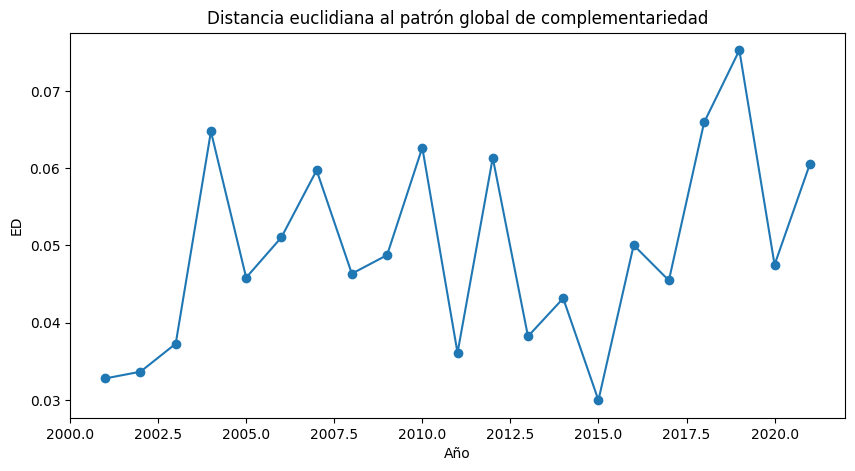

In [20]:
# Selección del año típico
typical_year, complementarity_summary, global_distribution = choose_typical_year(yearly_data)
print("Año típico seleccionado:", typical_year)
plot_typical_year_selection(complementarity_summary)

# Para replicar el paper, si quieres forzar 2008:
typical_year = 2008

df_tmy = yearly_data[typical_year].copy()

In [22]:
# Búsqueda principal
#t0 = time.time()
#results = run_grid_search(df_tmy, CONFIG, COSTS)
#t1 = time.time()
#print(f"Tiempo total: {t1 - t0:.2f} s")
#results.shape

## 8) Resultados principales

In [21]:
def summarize_results(results: pd.DataFrame):
    feasible = results[results["feasible"]].copy()
    infeasible = results[~results["feasible"]].copy()

    print("Total evaluados:", len(results))
    print("Factibles:", len(feasible))
    print("No factibles:", len(infeasible))

    if len(feasible) == 0:
        print("No hay soluciones factibles.")
        return feasible

    best = feasible.sort_values("lcoe_cny_per_kwh", ascending=True).iloc[0]
    display_cols = [
        "wind_mw", "pv_mw", "electrolyzer_mw", "battery_mw", "battery_mwh",
        "agsr", "electrolyzer_cf", "lcoe_cny_per_kwh", "lcoh_cny_per_kg",
        "total_grid_sales_mwh", "total_h2_kg", "npc_cny"
    ]
    display(best[display_cols])
    return feasible

feasible_results = summarize_results(results)

NameError: name 'results' is not defined

In [ ]:
def plot_feasible_domain(results: pd.DataFrame):
    tmp = results.copy()
    fig, ax = plt.subplots()

    infeasible = tmp[~tmp["feasible"]]
    feasible = tmp[tmp["feasible"]]

    ax.scatter(infeasible["wind_mw"], infeasible["electrolyzer_mw"], alpha=0.3, label="No factible")
    ax.scatter(feasible["wind_mw"], feasible["electrolyzer_mw"], alpha=0.8, label="Factible")

    if len(feasible) > 0:
        best = feasible.sort_values("lcoe_cny_per_kwh").iloc[0]
        ax.scatter([best["wind_mw"]], [best["electrolyzer_mw"]], s=120, marker="*", label="Óptimo")

    ax.set_xlabel("Wind capacity (MW)")
    ax.set_ylabel("Electrolyzer capacity (MW)")
    ax.set_title("Dominio factible WPEB")
    ax.legend()
    plt.show()

# plot_feasible_domain(results)

In [ ]:
def plot_lcoe_heatmap(results: pd.DataFrame):
    feasible = results[results["feasible"]].copy()
    if len(feasible) == 0:
        print("No hay puntos factibles para graficar.")
        return

    pivot = feasible.pivot_table(index="electrolyzer_mw", columns="wind_mw", values="lcoe_cny_per_kwh")
    plt.figure(figsize=(11, 7))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.xticks(range(len(pivot.columns)), [f"{c:.0f}" for c in pivot.columns], rotation=90)
    plt.yticks(range(len(pivot.index)), [f"{r:.0f}" for r in pivot.index])
    plt.xlabel("Wind capacity (MW)")
    plt.ylabel("Electrolyzer capacity (MW)")
    plt.title("Mapa de LCOE sobre el dominio factible")
    plt.colorbar(label="LCOE (CNY/kWh)")
    plt.show()

# plot_lcoe_heatmap(results)

## 9) Casos del paper para comparación directa

El paper compara:
- `W190-P10-E95-B30`
- `W120-P80-E80-B25`
- `W60-P140-E85-B27.5`

Este bloque los evalúa con el mismo modelo horario.

In [ ]:
def evaluate_named_cases(df_tmy: pd.DataFrame, config: Dict, costs: Dict) -> pd.DataFrame:
    cases = [
        ("W190-P10-E95", 190.0, 10.0, 95.0),
        ("W120-P80-E80", 120.0, 80.0, 80.0),
        ("W60-P140-E85", 60.0, 140.0, 85.0),
    ]
    rows = []
    for name, w, p, e in cases:
        res = simulate_wpeb(df_tmy, w, p, e, config, costs)
        row = asdict(res)
        row["case"] = name
        rows.append(row)
    return pd.DataFrame(rows)[[
        "case", "wind_mw", "pv_mw", "electrolyzer_mw",
        "battery_mw", "battery_mwh", "feasible", "agsr",
        "electrolyzer_cf", "lcoe_cny_per_kwh", "lcoh_cny_per_kg",
        "total_grid_sales_mwh", "total_h2_kg", "npc_cny"
    ]]

# case_table = evaluate_named_cases(df_tmy, CONFIG, COSTS)
# case_table

## 10) Validación contra el paper

Resultados objetivo reportados por el paper:
- óptimo: **W190-P10-E95-B30**
- **LCOE ≈ 0.2692 CNY/kWh**
- **CF del electrolizador ≈ 62.40%**
- **IRR ≈ 12.60%**
- **ROI ≈ 78.97%**

### Qué esperar
Con este notebook deberías obtener:
- un dominio factible parecido,
- una tendencia que favorezca **más capacidad eólica y menor PV**,
- un óptimo cercano a `W190-P10-E95-B30`,
- una reducción del LCOE al aumentar la razón wind/generation.

### Si tus números no calzan exactamente
Eso no significa que la replicación esté mal. Puede deberse a:
1. detalles del modelo original no publicados,
2. coordenadas exactas del sitio,
3. tratamiento de pérdidas,
4. definición exacta del NPC,
5. modelado específico de batería y electrolizador del ref. [59],
6. diferencias entre datos NASA POWER descargados hoy y los preprocesados por los autores.

## 11) Punto de partida para nuestro equipo

Este notebook ya deja listo el pipeline para que nosotros probemos:
- optimización monoobjetivo y multiobjetivo,
- metaheurísticas,
- estrategias de despacho del electrolizador,
- baterías de distinta duración,
- incorporación explícita de `NPV`, `IRR`, `ROI`,
- escenarios de precio de hidrógeno y feed-in tariff.

La parte más natural para intervenir después es:
- `simulate_wpeb(...)`
- `run_grid_search(...)`
- o reemplazar la búsqueda por nuestro optimizador.

In [ ]:
# Guardado opcional de resultados
# results.to_csv("wpeb_results_grid.csv", index=False)
# feasible_results.to_csv("wpeb_results_feasible.csv", index=False)
# case_table.to_csv("wpeb_case_comparison.csv", index=False)

## 12) Extensión discreta para **nuestro trabajo 1**

Esta sección extiende el simulador base con una formulación más realista de diseño-operación:

- electrólizador **modular** en unidades de 5 MW,
- batería con **potencia discreta** y **duración discreta**,
- operación con **carga mínima** del electrólizador,
- resolución mediante **metaheurísticas** sobre un espacio mixto.

### Variables de diseño
- `wind_share` (continua): capacidad eólica, con `pv_mw = 200 - wind_mw`
- `n_el_units` (entera): número de unidades de electrólisis de 5 MW
- `battery_mw` (discreta): potencia de batería en múltiplos de 5 MW
- `battery_duration_h` (discreta): duración en horas de la batería

### Importante
Esta extensión usa el **mismo contexto experimental** del notebook base, para conservar comparabilidad con el paper.


In [ ]:
# Parámetros adicionales para la extensión discreta
EXT_CONFIG = copy.deepcopy(CONFIG)

EXT_CONFIG.update({
    # Electrólizador modular
    "electrolyzer_unit_mw": 5.0,
    "min_electrolyzer_units": 10,   # 50 MW
    "max_electrolyzer_units": 20,   # 100 MW

    # Batería discreta
    "battery_power_step_mw": 5.0,
    "battery_power_min_mw": 0.0,
    "battery_power_max_mw": 50.0,
    "battery_duration_candidates_h": [1.0, 2.0, 4.0],

    # Metaheurística
    "gwo_population": 20,
    "gwo_iterations": 30,
    "random_seed": 42,
})

EXT_CONFIG


In [ ]:
from dataclasses import dataclass
from typing import Optional

@dataclass
class ExtendedSimulationResult:
    wind_mw: float
    pv_mw: float
    electrolyzer_mw: float
    n_el_units: int
    battery_mw: float
    battery_mwh: float
    battery_duration_h: float
    feasible: bool
    agsr: float
    total_wind_mwh: float
    total_pv_mwh: float
    total_renewable_mwh: float
    total_grid_sales_mwh: float
    total_electrolyzer_load_mwh: float
    electrolyzer_cf: float
    total_h2_kg: float
    npc_cny: float
    annualized_cost_cny: float
    lcoe_cny_per_kwh: float
    lcoh_cny_per_kg: float
    curtailment_mwh: float
    battery_throughput_mwh: float

def simulate_wpeb_extended(
    df: pd.DataFrame,
    wind_mw: float,
    n_el_units: int,
    battery_mw: float,
    battery_duration_h: float,
    config: Dict,
    costs: Dict,
) -> ExtendedSimulationResult:
    total_capacity = config["total_generation_capacity_mw"]
    pv_mw = total_capacity - wind_mw
    electrolyzer_mw = n_el_units * config["electrolyzer_unit_mw"]
    battery_mwh = battery_mw * battery_duration_h

    if wind_mw < 0 or pv_mw < 0 or abs(wind_mw + pv_mw - total_capacity) > 1e-9:
        return ExtendedSimulationResult(wind_mw, pv_mw, electrolyzer_mw, n_el_units, battery_mw, battery_mwh,
                                        battery_duration_h, False, np.nan, 0,0,0,0,0,0,0,0,0,np.inf,np.inf,0,0)

    if n_el_units < config["min_electrolyzer_units"] or n_el_units > config["max_electrolyzer_units"]:
        return ExtendedSimulationResult(wind_mw, pv_mw, electrolyzer_mw, n_el_units, battery_mw, battery_mwh,
                                        battery_duration_h, False, np.nan, 0,0,0,0,0,0,0,0,0,np.inf,np.inf,0,0)

    if battery_mw < config["battery_power_min_mw"] or battery_mw > config["battery_power_max_mw"]:
        return ExtendedSimulationResult(wind_mw, pv_mw, electrolyzer_mw, n_el_units, battery_mw, battery_mwh,
                                        battery_duration_h, False, np.nan, 0,0,0,0,0,0,0,0,0,np.inf,np.inf,0,0)

    if battery_duration_h not in config["battery_duration_candidates_h"]:
        return ExtendedSimulationResult(wind_mw, pv_mw, electrolyzer_mw, n_el_units, battery_mw, battery_mwh,
                                        battery_duration_h, False, np.nan, 0,0,0,0,0,0,0,0,0,np.inf,np.inf,0,0)

    if electrolyzer_mw > config["electrolyzer_ratio_max"] * total_capacity:
        return ExtendedSimulationResult(wind_mw, pv_mw, electrolyzer_mw, n_el_units, battery_mw, battery_mwh,
                                        battery_duration_h, False, np.nan, 0,0,0,0,0,0,0,0,0,np.inf,np.inf,0,0)

    p_wind = aggregate_wind_power_mw(df, wind_mw, config)
    p_pv = pv_power_mw(df, pv_mw, config)

    soc = 0.0
    soc_max = battery_mwh
    p_batt_max = battery_mw

    eta_rt = config["battery_roundtrip_efficiency"]
    eta_ch = math.sqrt(eta_rt)
    eta_dis = math.sqrt(eta_rt)

    min_elz = config["electrolyzer_min_load_ratio"] * electrolyzer_mw

    grid_sales = []
    electrolyzer_load = []
    curtailment = []
    batt_throughput = 0.0

    for gen in (p_wind + p_pv):
        p_elz = 0.0
        p_charge = 0.0
        p_discharge = 0.0
        p_grid = 0.0
        p_curt = 0.0

        # Regla operativa con carga mínima:
        # 1) si la generación ya alcanza el mínimo, operar
        # 2) si no alcanza, descargar batería para intentar sostener el mínimo
        # 3) si aun así no se alcanza, electrólizador apagado
        if gen >= min_elz and electrolyzer_mw > 0:
            p_elz = min(gen, electrolyzer_mw)
        elif electrolyzer_mw > 0 and p_batt_max > 0 and soc > 0:
            max_discharge = min(p_batt_max, soc * eta_dis)
            if gen + max_discharge >= min_elz:
                p_discharge = min(max_discharge, electrolyzer_mw - gen)
                p_elz = min(gen + p_discharge, electrolyzer_mw)

        surplus = gen + p_discharge - p_elz

        # Carga de batería con excedentes
        if surplus > 1e-12 and p_batt_max > 0 and soc_max > 0:
            max_charge_by_power = p_batt_max
            max_charge_by_soc = (soc_max - soc) / eta_ch if eta_ch > 0 else 0.0
            p_charge = min(surplus, max_charge_by_power, max_charge_by_soc)
            soc += p_charge * eta_ch
            surplus -= p_charge
            batt_throughput += p_charge

        # Si descargamos previamente, actualizar SOC
        if p_discharge > 0:
            soc -= p_discharge / eta_dis
            soc = max(soc, 0.0)
            batt_throughput += p_discharge

        # El remanente se vende a red
        if surplus > 1e-12:
            p_grid = surplus
        else:
            p_curt = 0.0

        grid_sales.append(p_grid)
        electrolyzer_load.append(p_elz)
        curtailment.append(p_curt)

    total_wind_mwh = float(np.sum(p_wind))
    total_pv_mwh = float(np.sum(p_pv))
    total_renewable_mwh = total_wind_mwh + total_pv_mwh
    total_grid_sales_mwh = float(np.sum(grid_sales))
    total_elz_mwh = float(np.sum(electrolyzer_load))
    electrolyzer_cf = total_elz_mwh / (electrolyzer_mw * len(df)) if electrolyzer_mw > 0 else 0.0

    agsr = (total_grid_sales_mwh / total_renewable_mwh) if total_renewable_mwh > 0 else np.inf
    feasible = agsr <= config["agsr_max"]

    # Producción de H2 con eficiencia simplificada del notebook base
    total_h2_kg = total_elz_mwh * 1000.0 / config["electrolyzer_specific_consumption_kwh_per_kg"]

    npc_cny = npc_from_capacities(wind_mw, pv_mw, electrolyzer_mw, battery_mw, config, costs)
    annualized_cost_cny = npc_cny * crf(config["real_discount_rate"], config["project_lifetime_years"])

    delivered_kwh = total_elz_mwh * 1000.0
    lcoe = annualized_cost_cny / delivered_kwh if feasible and delivered_kwh > 0 else np.inf
    lcoh = annualized_cost_cny / total_h2_kg if feasible and total_h2_kg > 0 else np.inf

    return ExtendedSimulationResult(
        wind_mw=wind_mw,
        pv_mw=pv_mw,
        electrolyzer_mw=electrolyzer_mw,
        n_el_units=int(n_el_units),
        battery_mw=battery_mw,
        battery_mwh=battery_mwh,
        battery_duration_h=battery_duration_h,
        feasible=bool(feasible),
        agsr=float(agsr),
        total_wind_mwh=total_wind_mwh,
        total_pv_mwh=total_pv_mwh,
        total_renewable_mwh=total_renewable_mwh,
        total_grid_sales_mwh=total_grid_sales_mwh,
        total_electrolyzer_load_mwh=total_elz_mwh,
        electrolyzer_cf=float(electrolyzer_cf),
        total_h2_kg=float(total_h2_kg),
        npc_cny=float(npc_cny),
        annualized_cost_cny=float(annualized_cost_cny),
        lcoe_cny_per_kwh=float(lcoe),
        lcoh_cny_per_kg=float(lcoh),
        curtailment_mwh=float(np.sum(curtailment)),
        battery_throughput_mwh=float(batt_throughput),
    )


In [ ]:
def decode_solution(x: np.ndarray, config: Dict) -> Dict:
    # x = [wind_mw, n_el_units_cont, battery_mw_cont, duration_index_cont]
    wind_mw = float(np.clip(x[0], 0.0, config["total_generation_capacity_mw"]))

    n_el_units = int(round(x[1]))
    n_el_units = int(np.clip(n_el_units, config["min_electrolyzer_units"], config["max_electrolyzer_units"]))

    batt_step = config["battery_power_step_mw"]
    battery_mw = round(float(x[2]) / batt_step) * batt_step
    battery_mw = float(np.clip(battery_mw, config["battery_power_min_mw"], config["battery_power_max_mw"]))

    dur_candidates = config["battery_duration_candidates_h"]
    dur_idx = int(round(x[3]))
    dur_idx = int(np.clip(dur_idx, 0, len(dur_candidates) - 1))
    battery_duration_h = float(dur_candidates[dur_idx])

    return {
        "wind_mw": wind_mw,
        "pv_mw": config["total_generation_capacity_mw"] - wind_mw,
        "n_el_units": n_el_units,
        "electrolyzer_mw": n_el_units * config["electrolyzer_unit_mw"],
        "battery_mw": battery_mw,
        "battery_duration_h": battery_duration_h,
        "battery_mwh": battery_mw * battery_duration_h,
    }

def objective_extended(x: np.ndarray, df_year: pd.DataFrame, config: Dict, costs: Dict,
                       penalty_infeasible: float = 1e6) -> Tuple[float, Dict]:
    d = decode_solution(x, config)
    res = simulate_wpeb_extended(
        df=df_year,
        wind_mw=d["wind_mw"],
        n_el_units=d["n_el_units"],
        battery_mw=d["battery_mw"],
        battery_duration_h=d["battery_duration_h"],
        config=config,
        costs=costs,
    )
    obj = res.lcoe_cny_per_kwh if res.feasible else penalty_infeasible + (0 if np.isnan(res.agsr) else 1e3 * res.agsr)
    return obj, asdict(res)


### Metaheurística 1: Grey Wolf Optimizer (GWO) híbrido

Se usa una versión simple de GWO sobre variables mixtas. La posición interna del agente es continua, pero la evaluación aplica **redondeo / proyección** para las variables discretas.


In [ ]:
def gwo_optimize_extended(
    df_year: pd.DataFrame,
    config: Dict,
    costs: Dict,
    n_wolves: Optional[int] = None,
    n_iter: Optional[int] = None,
    seed: Optional[int] = None,
):
    if n_wolves is None:
        n_wolves = config["gwo_population"]
    if n_iter is None:
        n_iter = config["gwo_iterations"]
    if seed is None:
        seed = config["random_seed"]

    rng = np.random.default_rng(seed)

    lb = np.array([
        0.0,
        config["min_electrolyzer_units"],
        config["battery_power_min_mw"],
        0.0,
    ], dtype=float)

    ub = np.array([
        config["total_generation_capacity_mw"],
        config["max_electrolyzer_units"],
        config["battery_power_max_mw"],
        len(config["battery_duration_candidates_h"]) - 1,
    ], dtype=float)

    X = rng.uniform(lb, ub, size=(n_wolves, 4))
    scores = np.full(n_wolves, np.inf)
    records = []

    alpha = {"score": np.inf, "x": None, "info": None}
    beta  = {"score": np.inf, "x": None, "info": None}
    delta = {"score": np.inf, "x": None, "info": None}

    for it in range(n_iter):
        for i in range(n_wolves):
            X[i] = np.clip(X[i], lb, ub)
            score, info = objective_extended(X[i], df_year, config, costs)
            scores[i] = score

            if score < alpha["score"]:
                delta = beta.copy()
                beta = alpha.copy()
                alpha = {"score": score, "x": X[i].copy(), "info": info}
            elif score < beta["score"]:
                delta = beta.copy()
                beta = {"score": score, "x": X[i].copy(), "info": info}
            elif score < delta["score"]:
                delta = {"score": score, "x": X[i].copy(), "info": info}

        a = 2 - it * (2 / max(n_iter - 1, 1))

        for i in range(n_wolves):
            for j in range(X.shape[1]):
                r1, r2 = rng.random(), rng.random()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = abs(C1 * alpha["x"][j] - X[i, j])
                X1 = alpha["x"][j] - A1 * D_alpha

                r1, r2 = rng.random(), rng.random()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = abs(C2 * beta["x"][j] - X[i, j])
                X2 = beta["x"][j] - A2 * D_beta

                r1, r2 = rng.random(), rng.random()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = abs(C3 * delta["x"][j] - X[i, j])
                X3 = delta["x"][j] - A3 * D_delta

                X[i, j] = (X1 + X2 + X3) / 3.0

        best_row = {"iteration": it + 1, "best_score": alpha["score"]}
        if alpha["info"] is not None:
            best_row.update({
                "wind_mw": alpha["info"]["wind_mw"],
                "pv_mw": alpha["info"]["pv_mw"],
                "electrolyzer_mw": alpha["info"]["electrolyzer_mw"],
                "n_el_units": alpha["info"]["n_el_units"],
                "battery_mw": alpha["info"]["battery_mw"],
                "battery_mwh": alpha["info"]["battery_mwh"],
                "battery_duration_h": alpha["info"]["battery_duration_h"],
                "agsr": alpha["info"]["agsr"],
                "lcoe_cny_per_kwh": alpha["info"]["lcoe_cny_per_kwh"],
                "lcoh_cny_per_kg": alpha["info"]["lcoh_cny_per_kg"],
                "feasible": alpha["info"]["feasible"],
            })
        records.append(best_row)

    return pd.DataFrame(records), alpha


In [ ]:
def random_baseline_extended(
    df_year: pd.DataFrame,
    config: Dict,
    costs: Dict,
    n_samples: int = 500,
    seed: Optional[int] = None,
):
    if seed is None:
        seed = config["random_seed"]

    rng = np.random.default_rng(seed)
    rows = []

    for _ in range(n_samples):
        x = np.array([
            rng.uniform(0.0, config["total_generation_capacity_mw"]),
            rng.integers(config["min_electrolyzer_units"], config["max_electrolyzer_units"] + 1),
            rng.choice(np.arange(config["battery_power_min_mw"], config["battery_power_max_mw"] + 1e-9, config["battery_power_step_mw"])),
            rng.integers(0, len(config["battery_duration_candidates_h"])),
        ], dtype=float)

        score, info = objective_extended(x, df_year, config, costs)
        info["score"] = score
        rows.append(info)

    return pd.DataFrame(rows).sort_values("score").reset_index(drop=True)


## 13) Ejecución sugerida

1. Ejecuta primero el notebook base y deja disponible `df_tmy`.
2. Corre el baseline aleatorio.
3. Ejecuta GWO.
4. Compara la mejor solución discreta con el caso continuo del paper y con el mejor caso de tu replicación base.


In [ ]:
# ===== EJEMPLO DE EJECUCIÓN =====
# Requiere que ya exista df_tmy desde la parte base del notebook.

baseline_random = random_baseline_extended(df_tmy, EXT_CONFIG, COSTS, n_samples=400, seed=42)
display(baseline_random.head(10))

In [ ]:
# ===== EJECUCIÓN DE GWO =====
history_gwo, best_gwo = gwo_optimize_extended(
    df_year=df_tmy,
    config=EXT_CONFIG,
    costs=COSTS,
    n_wolves=20,
    n_iter=30,
    seed=42,
)
display(history_gwo.tail())
display(best_gwo["info"])

In [ ]:
def summarize_extended_solution(best_info: Dict) -> pd.DataFrame:
    cols = [
        "wind_mw", "pv_mw", "electrolyzer_mw", "n_el_units",
        "battery_mw", "battery_mwh", "battery_duration_h",
        "feasible", "agsr", "electrolyzer_cf", "lcoe_cny_per_kwh",
        "lcoh_cny_per_kg", "total_h2_kg", "npc_cny"
    ]
    return pd.DataFrame([{k: best_info.get(k) for k in cols}])

if 'best_gwo' in globals():
    display(summarize_extended_solution(best_gwo["info"]))

In [ ]:
def plot_gwo_history(history_gwo: pd.DataFrame):
    plt.figure(figsize=(8, 4))
    plt.plot(history_gwo["iteration"], history_gwo["best_score"], marker="o")
    plt.xlabel("Iteración")
    plt.ylabel("Mejor LCOE penalizado")
    plt.title("Convergencia de GWO — nuestro trabajo 1")
    plt.grid(True, alpha=0.3)
    plt.show()

if 'history_gwo' in globals():
    plot_gwo_history(history_gwo)

## 14) Próximos pasos para artículo

Con este notebook ya puedes:

- obtener una primera solución factible con diseño discreto,
- comparar contra el óptimo continuo del paper,
- medir sensibilidad a `electrolyzer_min_load_ratio`,
- luego escalar a:
  - múltiples corridas y estadística,
  - comparación con PSO / WOA / GWO,
  - formulación multiobjetivo con **ε-constraint**.


In [ ]:
# Guardado opcional de resultados extendidos
# baseline_random.to_csv("wpeb_trabajo1_random_baseline.csv", index=False)
# history_gwo.to_csv("wpeb_trabajo1_gwo_history.csv", index=False)
# summarize_extended_solution(best_gwo["info"]).to_csv("wpeb_trabajo1_best_solution.csv", index=False)
